# Statistical Evaluation: Haiku vs Opus on Exam Problems

*All inference (hypothesis tests **and** confidence intervals) uses `alpha = 0.01` (99% CIs), consistent with the pilot / power analysis designed at $\alpha = 0.01$, power $= 0.90$.*

In [15]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

# Significance level for ALL inference (hypothesis tests + confidence intervals) alpha = 0.01 to stay consistent with the pilot / power analysis, which was 
# designed at alpha = 0.01 and power = 0.90 (required n = 45; achieved n = 54).
alpha = 0.01
REPS  = 5

## 1. Load and clean data

In [16]:
DATA_PATH = "Dataset.csv"

df = pd.read_csv(DATA_PATH, sep=";", encoding="utf-8-sig")
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]
df.columns = df.columns.str.strip()
df = df.rename(columns={"Haiko True": "Haiku True",
                        "Haiko False": "Haiku False"})
df["Q_Type"] = df["Q_Type"].str.strip().replace({"Knowlegde": "Knowledge"})
df

,Examset,Question,Q_Type,Haiku True,Haiku False,Opus True,Opus False
0,Spring 2025,1,Visual,5,0,5,0
1,Spring 2025,2,Visual,0,5,5,0
2,Spring 2025,3,Computational,0,5,5,0
3,Spring 2025,4,Visual,4,1,4,1
4,Spring 2025,5,Knowledge,0,5,5,0
5,Spring 2025,6,Computational,1,4,5,0
6,Spring 2025,7,Computational,0,5,5,0
7,Spring 2025,8,Computational,0,5,5,0
8,Spring 2025,9,Visual,0,5,5,0
9,Spring 2025,10,Computational,0,5,1,4


## 2. Sanity checks

In [17]:
assert len(df) == 54, f"Expected 54 questions, got {len(df)}"
ok_h = (df["Haiku True"] + df["Haiku False"] == REPS).all()
ok_o = (df["Opus True"]  + df["Opus False"]  == REPS).all()
print("54 questions:", len(df) == 54)
print("5 repetitions per question (Haiku/Opus):", bool(ok_h), bool(ok_o))
print("\nQuestions per type:\n", df["Q_Type"].value_counts().to_string())
print("\nQuestions per exam set:\n", df["Examset"].value_counts().to_string())

54 questions: True
5 repetitions per question (Haiku/Opus): True True

Questions per type:
 Q_Type
Visual           27
Computational    17
Knowledge        10

Questions per exam set:
 Examset
Spring 2025    27
Fall 2025      27


## 3. Pilot study

In [18]:
pilot_path = "final pilot.csv"
df_pilot_study = pd.read_csv(pilot_path, sep=";", encoding="utf-8-sig", skiprows=2)
df_pilot_study.columns = ['ID', 'Semester', 'Question', 'Haiku_True', 'Haiku_False', 'Opus_True', 'Opus_False']
df_pilot_study = df_pilot_study.fillna(0)
df_pilot_study

,ID,Semester,Question,Haiku_True,Haiku_False,Opus_True,Opus_False
0,2,Fall 2025,B,0.0,1.0,1.0,0.0
1,3,Fall 2025,A,1.0,0.0,1.0,0.0
2,4,Fall 2025,D,1.0,0.0,1.0,0.0
3,5,Fall 2025,C,1.0,0.0,1.0,0.0
4,6,Fall 2025,B,0.0,1.0,0.0,1.0
5,7,Fall 2025,A,1.0,0.0,1.0,0.0
6,8,Fall 2025,C,1.0,0.0,1.0,0.0
7,9,Fall 2025,B,1.0,0.0,1.0,0.0
8,10,Fall 2025,D,1.0,0.0,0.0,1.0
9,11,Fall 2025,A,0.0,1.0,1.0,0.0


In [19]:
haiku_correct = df_pilot_study['Haiku_True'].sum()
opus_correct = df_pilot_study['Opus_True'].sum()

accuracy_haiku = haiku_correct / 27
accuracy_opus = opus_correct / 27

print(f"Haiku: {int(haiku_correct)}/27 = {accuracy_haiku:.1%}")
print(f"Opus:  {int(opus_correct)}/27 = {accuracy_opus:.1%}")

Haiku: 16/27 = 59.3%
Opus:  23/27 = 85.2%


## 4. Sample size estimation (McNemar-based)

In [20]:
b = 0
c = 8
n_pilot = 27

alfa  = alpha
power = 0.90
z_alfa_2 = st.norm.ppf(1 - alfa/2)
z_beta   = st.norm.ppf(power)

p_disc = (b + c) / n_pilot
delta  = (c - b) / n_pilot

n_req = (z_alfa_2 * np.sqrt(p_disc) + z_beta * np.sqrt(p_disc - delta**2))**2 / delta**2
n_req = int(np.ceil(n_req))
print(f"Required n  (alpha = {alfa}, power = {power:.0%}):  {n_req}")

Required n  (alpha = 0.01, power = 90%):  45


## 5. Exact power

In [21]:
n_target = 54
z_beta_achieved = (np.sqrt(n_target) * delta - z_alfa_2 * np.sqrt(p_disc)) / np.sqrt(p_disc - delta**2)
power_achieved = st.norm.cdf(z_beta_achieved)
print(f"Power at n = {n_target}: {power_achieved:.1%}")
print(f"alpha = 0.01")

Power at n = 54: 95.5%
alpha = 0.01


## 6. Binarization: majority vote

In [22]:
df["Haiku_bin"] = (df["Haiku True"] > df["Haiku False"]).astype(int)
df["Opus_bin"]  = (df["Opus True"]  > df["Opus False"]).astype(int)
n = len(df)
print(f"Haiku solved {df['Haiku_bin'].sum()}/{n} questions")
print(f"Opus  solved {df['Opus_bin'].sum()}/{n} questions")

Haiku solved 23/54 questions
Opus  solved 46/54 questions


## 7. Accuracy per model with Jeffreys 99% CI (n = 54)

JEFFREYS INTERVAL (99% CI)  -  n = 54

Haiku:  theta = 0.427   CI = [0.265, 0.600]
Opus:   theta = 0.845   CI = [0.700, 0.945]


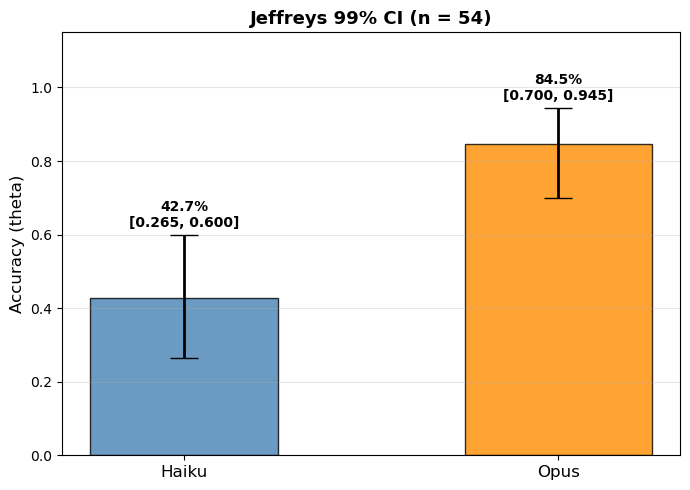

In [23]:
def jeffrey_interval(m, n, alpha=0.01):
    a, b = m + 0.5, n - m + 0.5
    return a / (a + b), st.beta.interval(1 - alpha, a, b)

m_h, m_o = df["Haiku_bin"].sum(), df["Opus_bin"].sum()
th_h, ci_h = jeffrey_interval(m_h, n, alpha)
th_o, ci_o = jeffrey_interval(m_o, n, alpha)
print(f"JEFFREYS INTERVAL ({1 - alpha:.0%} CI)  -  n = 54")
print(f"\nHaiku:  theta = {th_h:.3f}   CI = [{ci_h[0]:.3f}, {ci_h[1]:.3f}]")
print(f"Opus:   theta = {th_o:.3f}   CI = [{ci_o[0]:.3f}, {ci_o[1]:.3f}]")

fig, ax = plt.subplots(figsize=(7, 5))
for i, (mdl, th, ci, c) in enumerate(zip(["Haiku","Opus"], [th_h,th_o],
                                         [ci_h,ci_o], ["steelblue","darkorange"])):
    ax.bar(i, th, color=c, alpha=0.8, edgecolor="black", width=0.5)
    ax.errorbar(i, th, yerr=[[th-ci[0]],[ci[1]-th]], fmt="none",
                color="black", capsize=10, linewidth=2)
    ax.text(i, ci[1]+0.02, f"{th:.1%}\n[{ci[0]:.3f}, {ci[1]:.3f}]",
            ha="center", fontsize=10, fontweight="bold")
ax.set_xticks([0,1]); ax.set_xticklabels(["Haiku","Opus"], fontsize=12)
ax.set_ylim([0,1.15]); ax.set_ylabel("Accuracy (theta)", fontsize=12)
ax.set_title(f"Jeffreys {1 - alpha:.0%} CI (n = 54)", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y"); plt.tight_layout(); plt.show()

## 8. Majority-vote accuracy per category with Jeffreys 99% CI

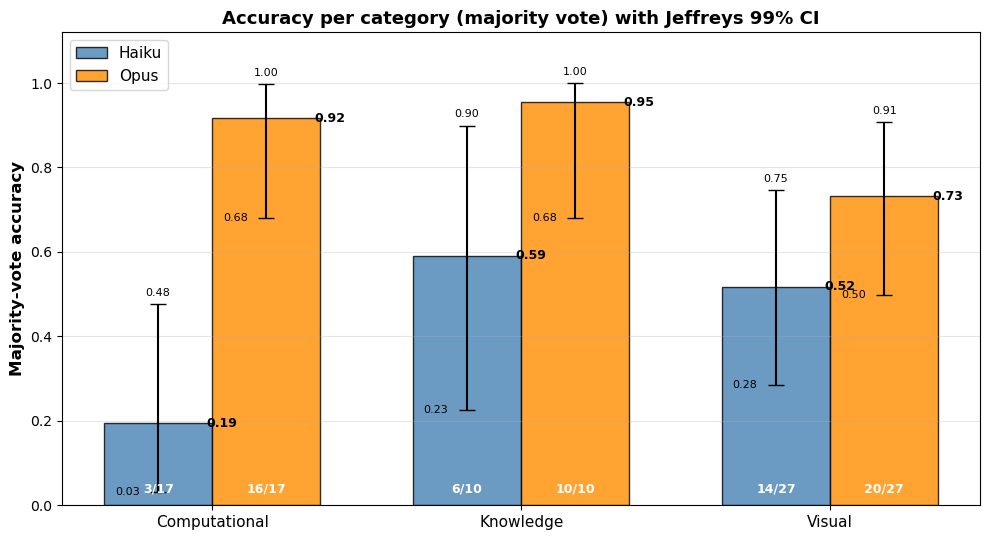

In [24]:
cats = sorted(df["Q_Type"].unique())
fig, ax = plt.subplots(figsize=(10, 5.5))
width = 0.35; x = np.arange(len(cats))
for j, (col, name, c) in enumerate([("Haiku_bin","Haiku","steelblue"),
                                    ("Opus_bin","Opus","darkorange")]):
    ths, lo, hi, labels, cis = [], [], [], [], []
    for qt in cats:
        sub = df[df["Q_Type"] == qt]; m = int(sub[col].sum()); nq = len(sub)
        th, ci = jeffrey_interval(m, nq, alpha)
        ths.append(th); lo.append(th-ci[0]); hi.append(ci[1]-th)
        labels.append(f"{m}/{nq}"); cis.append(ci)
    pos = x + (j - 0.5) * width
    ax.bar(pos, ths, width, color=c, alpha=0.8, edgecolor="black", label=name)
    ax.errorbar(pos, ths, yerr=[lo, hi], fmt="none", color="black", capsize=6, linewidth=1.5)
    for p_, t_, l_, ci_ in zip(pos, ths, labels, cis):
        ax.text(p_, 0.03, l_, ha="center", fontsize=9, fontweight="bold", color="white")
        ax.text(p_ + width/2 - 0.02, t_, f"{t_:.2f}", ha="left", va="center",
                fontsize=9, fontweight="bold", color="black")
        ax.text(p_, ci_[1] + 0.015, f"{ci_[1]:.2f}", ha="center", va="bottom", fontsize=8)
        ax.text(p_ - 0.06, ci_[0], f"{ci_[0]:.2f}", ha="right", va="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(cats, fontsize=11)
ax.set_ylabel("Majority-vote accuracy", fontsize=12, fontweight="bold")
ax.set_title(f"Accuracy per category (majority vote) with Jeffreys {1 - alpha:.0%} CI", fontsize=13, fontweight="bold")
ax.set_ylim([0, 1.12]); ax.legend(fontsize=11, loc="upper left"); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

## 9. McNemar's test (paired, n = 54)

Both correct:            21
Only Opus correct:       25
Only Haiku correct:      2
Both wrong:              6
Discordant pairs:        27

theta (Opus - Haiku):    +0.426
99% CI:                 [0.220, 0.609]
p-value:                 5.65e-06


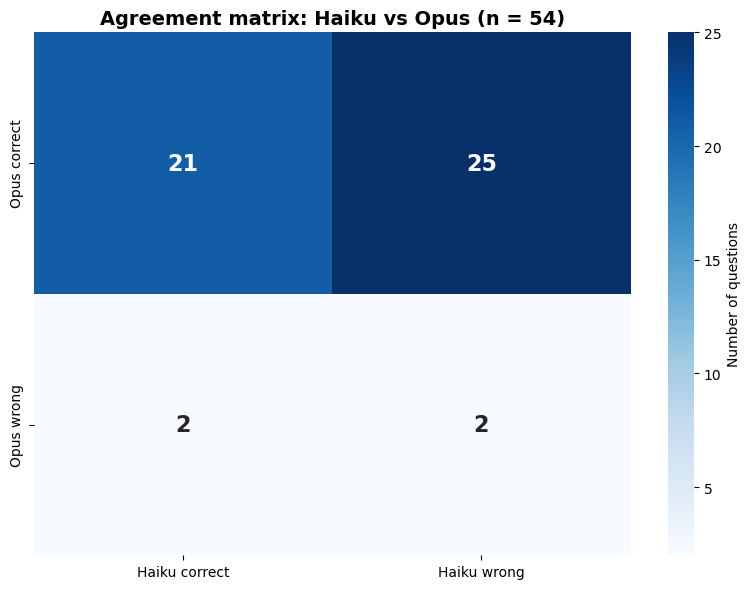

In [25]:
def mcnemar(yA, yB, alpha=0.01):
    cA, cB = yA == 1, yB == 1
    n11 = int((cA &  cB).sum())
    n12 = int((cA & ~cB).sum())
    n21 = int((~cA & cB).sum())
    n22 = int((~cA & ~cB).sum())
    N = len(yA); E = (n12 - n21) / N
    Q = (N**2 * (N+1) * (E+1) * (1-E)) / (N*(n12+n21) - (n12-n21)**2)
    f = (E+1)/2 * (Q-1); g = (1-E)/2 * (Q-1)
    CI = tuple(b*2 - 1 for b in st.beta.interval(1-alpha, a=f, b=g))
    p  = 2 * st.binom.cdf(min(n12, n21), n=n12+n21, p=0.5)
    return E, CI, p, (n11, n12, n21, n22)

E, CI_mc, p_mc, (n11, n12, n21, n22) = mcnemar(df["Opus_bin"].values, df["Haiku_bin"].values, alpha=alpha)
print(f"Both correct:            {n11}")
print(f"Only Opus correct:       {n12}")
print(f"Only Haiku correct:      {n21}")
print(f"Both wrong:              {n22}")
print(f"Discordant pairs:        {n12 + n21}")
print(f"\ntheta (Opus - Haiku):    {E:+.3f}")
print(f"{1 - alpha:.0%} CI:                 [{CI_mc[0]:.3f}, {CI_mc[1]:.3f}]")
print(f"p-value:                 {p_mc:.2e}")

matrix = np.array([[n11, n12], [n21, n21]])
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", ax=ax,
            yticklabels=["Opus correct","Opus wrong"],
            xticklabels=["Haiku correct","Haiku wrong"],
            cbar_kws={"label":"Number of questions"}, annot_kws={"size":16,"weight":"bold"})
ax.set_title("Agreement matrix: Haiku vs Opus (n = 54)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## 10. McNemar: distribution of theta

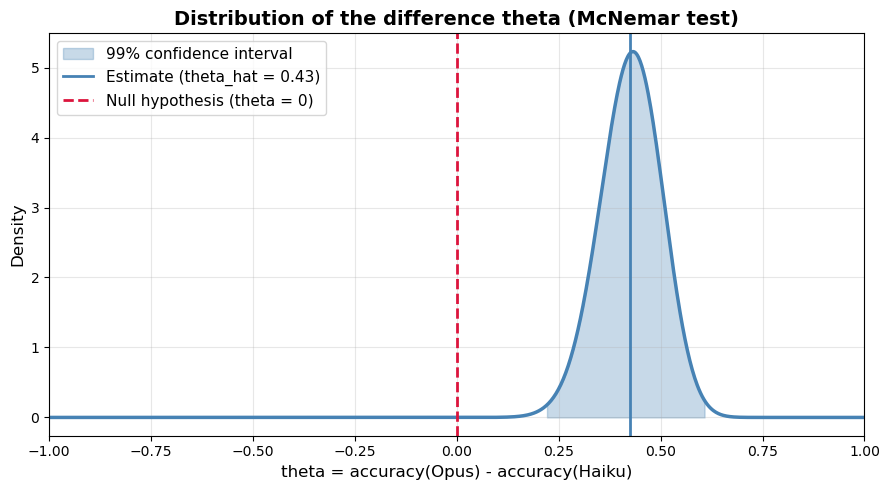

In [26]:
N = len(df)
E_plot = (n12 - n21) / N
Q_plot = N**2 * (N + 1) * (E_plot + 1) * (1 - E_plot) / (N * (n12 + n21) - (n12 - n21)**2)
f_plot = (E_plot + 1) / 2 * (Q_plot - 1)
g_plot = (1 - E_plot) / 2 * (Q_plot - 1)

theta = np.linspace(-1, 1, 1000)
density = 0.5 * st.beta.pdf((theta + 1) / 2, a=f_plot, b=g_plot)

plt.figure(figsize=(9, 5))
plt.plot(theta, density, color="steelblue", linewidth=2.5)
inside = (theta >= CI_mc[0]) & (theta <= CI_mc[1])
plt.fill_between(theta[inside], density[inside], color="steelblue", alpha=0.3,
                 label=f"{1 - alpha:.0%} confidence interval")
plt.axvline(E, color="steelblue", linewidth=2, label=f"Estimate (theta_hat = {E:.2f})")
plt.axvline(0, color="crimson", linestyle="--", linewidth=2, label="Null hypothesis (theta = 0)")
plt.xlabel("theta = accuracy(Opus) - accuracy(Haiku)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title("Distribution of the difference theta (McNemar test)", fontsize=14, fontweight="bold")
plt.legend(fontsize=11); plt.grid(alpha=0.3); plt.margins(x=0)
plt.tight_layout(); plt.show()

## 11. Wilcoxon signed-rank (continuous track, n = 54)

In [ ]:
df["Haiku_acc"] = df["Haiku True"] / REPS
df["Opus_acc"]  = df["Opus True"]  / REPS

results = {"Overall": [df["Haiku_acc"].mean(), df["Opus_acc"].mean()]}
for qtype in sorted(df["Q_Type"].unique()):
    sub = df[df["Q_Type"] == qtype]
    results[qtype] = [sub["Haiku_acc"].mean(), sub["Opus_acc"].mean()]


diff = df["Opus_acc"] - df["Haiku_acc"]
res = st.wilcoxon(df["Opus_acc"], df["Haiku_acc"], zero_method="wilcox", alternative="two-sided")
d = diff[diff != 0].to_numpy(); ranks = st.rankdata(np.abs(d))
W_plus  = ranks[d > 0].sum()
W_minus = ranks[d < 0].sum()
rbc = (W_plus - W_minus) / ranks.sum()
print(f"Non-tied pairs:          {int((diff != 0).sum())}")
print(f"W+ statistic:            {W_plus:.1f}")
print(f"W- statistic:            {W_minus:.1f}")
print(f"p-value:                 {res.pvalue:.2e}")
print(f"Median difference (O-H): {np.median(diff):+.3f}")
print(f"Mean difference (O-H):   {diff.mean():+.3f}")
print(f"Rank-biserial r:         {rbc:.3f}")
print(f"Significant at alpha = {alpha}: {bool(res.pvalue < alpha)}")

Non-tied pairs:          36
W+ statistic:            615.0
W- statistic:            51.0
p-value:                 6.40e-06
Median difference (O-H): +0.400
Mean difference (O-H):   +0.415
Rank-biserial r:         0.847
Significant at alpha = 0.01: True


## 12. Boxplot: distribution of per-question accuracy

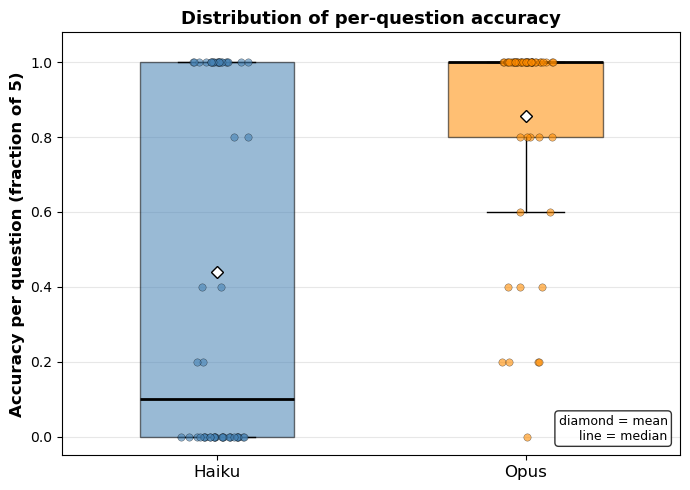

In [28]:
np.random.seed(0)
data = [df["Haiku_acc"], df["Opus_acc"]]; colors = ["steelblue","darkorange"]
fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot(data, patch_artist=True, widths=0.5, showmeans=True, showfliers=False,
                meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black"))
for patch, c in zip(bp["boxes"], colors): patch.set_facecolor(c); patch.set_alpha(0.55)
for med in bp["medians"]: med.set_color("black"); med.set_linewidth(2)
for i, (dd, c) in enumerate(zip(data, colors), start=1):
    ax.scatter(np.random.normal(i, 0.045, size=len(dd)), dd, color=c,
               alpha=0.6, edgecolor="black", linewidth=0.3, zorder=3, s=28)
ax.set_xticks([1, 2]); ax.set_xticklabels(["Haiku","Opus"], fontsize=12)
ax.set_ylabel("Accuracy per question (fraction of 5)", fontsize=12, fontweight="bold")
ax.set_title("Distribution of per-question accuracy", fontsize=13, fontweight="bold")
ax.set_ylim(-0.05, 1.08); ax.grid(True, alpha=0.3, axis="y")
ax.text(0.98, 0.03, "diamond = mean\nline = median", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=9, bbox=dict(boxstyle="round", fc="white", alpha=0.8))
plt.tight_layout(); plt.show()